### Testing the nodal --> modal code 1D

**This code does pure transform checks**
* modal $\to$ nodal $\to$ modal: coefficient error
* nodal $\to$ modal $\to$ nodal: nodal error

Expectation: machine precision


In [1]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("../..")

In [ ]:
from src.mesh import build_uniform_mesh_1d
from src.grid import local_cell_center_nodes_1d, build_grid_from_local_nodes_1d
from src.transforms import nodal_to_modal_1d, modal_to_nodal_1d, vandermonde_1d
from src.testing.helpers_1d import random_modal_coeffs_1d
from src.basis import eval_orthonormal_legendre_1d

In [3]:
# setup
xmin, xmax = -1, 1
xlim = (xmin, xmax)

# mesh
K = 16
p = 3
order = p + 1
mesh = build_uniform_mesh_1d(K=K, p=p, domain=xlim)


#### Begin with the modal --> nodal --> modal roundtrip test ####
# generate random DG modal coefficients
coeffs_init = random_modal_coeffs_1d(K=K, p=p, seed=62, scale=1.0)

# choose cell centers as evaluation points (for nodal --> modal, need exactly p + 1 points per element)
n_eval = order
eval_nodes = local_cell_center_nodes_1d(nloc=n_eval)

# evaluate the random modal coeffiecients at nodal locations
# the modal --> nodal code requires a dictionary with vandermonde matrix and modal coefficients atleast
V, Vinv = vandermonde_1d(nodes=eval_nodes, p=p)
dg_init = {
    "coeffs": coeffs_init, 
    "V": V
}

_, Unode = modal_to_nodal_1d(dg_init, return_blocks=True)

# transform this result back into modal coefficients
dg_result = nodal_to_modal_1d(Unode=Unode, mesh=mesh, p=p)

# compare coefficient errors:
coeffs_result = dg_result["coeffs"]

coeffs_err = coeffs_init - coeffs_result

coeff_err_rel_inf = np.max(np.abs(coeffs_err)) / np.max(np.abs(coeffs_init))
coeff_err_rel_l2 = np.linalg.norm(coeffs_err.ravel()) / np.linalg.norm(coeffs_init.ravel())

print("Relative coefficient error (inf) =", coeff_err_rel_inf)
print("Relative coefficient error (l2)  =", coeff_err_rel_l2)


Relative coefficient error (inf) = 2.5180366778313786e-16
Relative coefficient error (l2)  = 2.2742785373908076e-16


In [4]:
#### nodal --> modal --> nodal rountrip test

_, Unode_recovered = modal_to_nodal_1d(dg_result, return_blocks=True)

nodal_err = Unode - Unode_recovered
nodal_err_max = np.max(np.abs(nodal_err))
nodal_err_rel_l2 = np.linalg.norm(nodal_err.ravel()) / np.linalg.norm(Unode.ravel())

print("Max nodal reconstruction error =", nodal_err_max)
print("Relative nodal l2 error        =", nodal_err_rel_l2)

Max nodal reconstruction error = 8.881784197001252e-16
Relative nodal l2 error        = 2.3463888554048934e-16


**Condition number for the Vandermonde matrix**

We additionally take a look at the condition number for the Vandermonde matrix as the DG degree $p$ increases

Condition numbers for first p values:
p =  0  ->  cond(V) = 1.000e+00
p =  1  ->  cond(V) = 1.155e+00
p =  2  ->  cond(V) = 1.465e+00
p =  3  ->  cond(V) = 2.018e+00
p =  4  ->  cond(V) = 3.038e+00
p =  5  ->  cond(V) = 4.968e+00
p =  6  ->  cond(V) = 8.647e+00
p =  7  ->  cond(V) = 1.559e+01


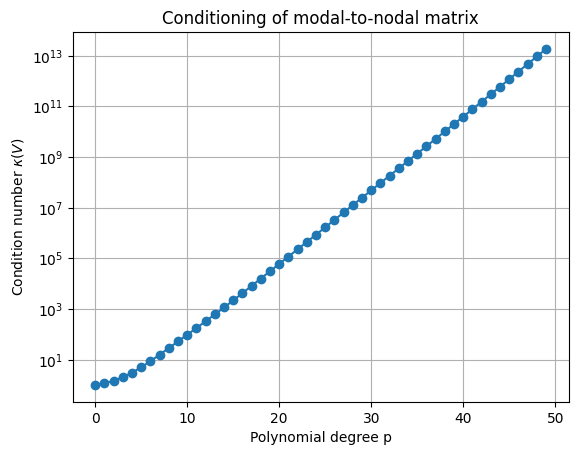

In [5]:
ps = np.arange(50)
condVs = np.zeros_like(ps, dtype=float)

for i, p in enumerate(ps):
    order = int(p + 1)
    eval_nodes = local_cell_center_nodes_1d(nloc=order)

    V = eval_orthonormal_legendre_1d(x=eval_nodes, p=p)
    condVs[i] = np.linalg.cond(V)

# print first few nicely
print("Condition numbers for first p values:")
for i in range(8):
    print(f"p = {ps[i]:2d}  ->  cond(V) = {condVs[i]:.3e}")

# plot
plt.figure()
plt.semilogy(ps, condVs, marker='o')
plt.xlabel("Polynomial degree p")
plt.ylabel(r"Condition number $\kappa(V)$")
plt.title("Conditioning of modal-to-nodal matrix")
plt.grid(True)
plt.show()